# L8c Lab: Residuals Reveal a Missing Nonlinearity

> **Learning objectives**
>
> - Use residual structure to detect model misspecification.
> - Compare linear and quadratic feature maps on the same observations.
> - Report prediction metrics alongside plots.
> - Distinguish adding a justified feature from blindly increasing complexity.


## Setup


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


In [2]:
x = collect(range(-3.0, 3.0; length = 80))
noise = 0.25 .* sin.(11 .* x)
y = 2.0 .+ 1.5 .* x .+ 0.8 .* x.^2 .+ noise

linear = ridge_fit(reshape(x, :, 1), y, 0.0)
quadratic = ridge_fit(hcat(x, x.^2), y, 0.0)
linear_report = model_metrics(y, linear.predictions)
quadratic_report = model_metrics(y, quadratic.predictions)
DataFrame(model = ["linear", "quadratic"], rmse = [linear_report.rmse, quadratic_report.rmse],
    r2 = [linear_report.r2, quadratic_report.r2]) |> pretty_table


┌───────────┬──────────┬──────────┐
│     model │     rmse │       r2 │
│    String │  Float64 │  Float64 │
├───────────┼──────────┼──────────┤
│    linear │  2.20763 │ 0.587878 │
│ quadratic │ 0.177806 │ 0.997327 │
└───────────┴──────────┴──────────┘


In [3]:
@test quadratic_report.rmse < 0.25 * linear_report.rmse
@test quadratic_report.r2 > 0.99
:residual_model_check_verified


:residual_model_check_verified

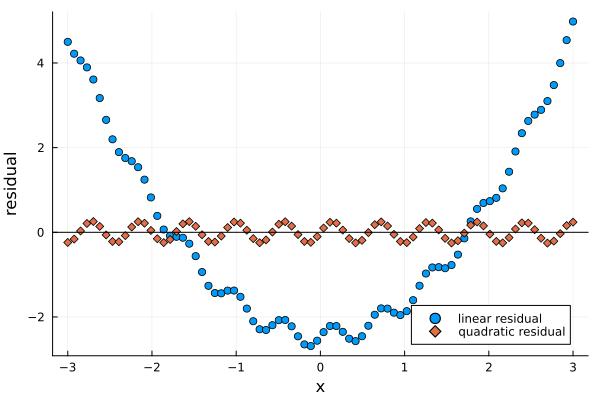

In [4]:
scatter(x, y - linear.predictions; label = "linear residual", xlabel = "x", ylabel = "residual")
scatter!(x, y - quadratic.predictions; label = "quadratic residual", marker = :diamond)
hline!([0.0]; color = :black, label = "")


## Summary

The curved residual pattern is evidence that the linear feature map misses structure. The quadratic model removes that pattern here because the data-generating example actually contains a quadratic term.
